# Gruppearbeid: Matematikk og mekanikk

## Fagverk og lineær algebra

I Mekanikk 1 ser vi på 2-dimensjonale fagverk, hvor det store spørsmålet er hva trykk/strekk på alle staver når systemer er i ro (likevekt) men under påvirkning av eksterne laster. Dette analyse av et fagverk er tredelt:
1. Det settes opp et lineært system
2. Systemet må løses
3. Resultatet må tolkes

Dette prosjektet fokuserer på hvordan vi kan automisere punkt i), og løser ii), ved hjelp av det vi har lært fra Programmering, Numerikk og Sikkerhet og Matematikk 1. Fagverk viser seg å være et knutepunkt for første semesteret!

## Del 1 - Sett opp systemet

Det er kanskje ikke så åpenbart, men hvis vi leser nøyere innholdet i læreboka om fagverk ser vi at ligningene for trykk/strekk i stavene danner et lineært system av type $L \vec{u} = \vec{f}$, hvor vi kan kalle $L$ for en stivhetsmatrise. I mer detalj:
1. $\vec{u}=(u_1,u_2,\ldots)$ er en vektor hvor $u_i$ er strekk/trykk i stav nummer $i$.
2. $\vec{f}=(f_{1x}, f_{1y}, f_{2x}, f_{2y}, \ldots)$ er en vektor med $2m$ komponenter, hvor $m$ er antall noder, som inneholder eksterne krefter i $x$- og $y$-retninger på hver node.
3. $L_{ij}$ er en matrise hvor $i=1,\ldots,2m$ er node/retning (som i kreft-vektoren) og $j=1,\ldots,n$ er stavnummeret (som i strekk/trykk-vektoren). Komponenten $(i,j)$ er lik
* $\cos(\theta)$ hvis $i$ er en $x$-retning og stav $j$ er knyttet til node $i$, og har vinkel $\theta$ med $x$-aksen,
* $\sin(\theta)$ hvis $i$ er en $y$-retning og stav $j$ er knyttet til node $i$, og har vinkel $\theta$ med $x$-aksen,
* $0$ hvis ikke stav $j$ er knyttet til node $i$.

En ekstra komplikasjon er at det finnes randbetingelser, dvs noder som er festet til bakken i en ("glidelager") eller begge retninger ("fastlager"). De funker som usynlige staver, dvs indexen $j$ kan være en slik "reaksjonskraft" (i tillegg til en stav). For en slik $j$ er
* $f_j=0$
* $L_{ij}=1$ hvis $i$ er festet til bakken i retningen som innegår i $i$
* $L_{ij}=0$ ellers

Matrisa $L$ har ikke nødvendigvis samme antall rader og kolonner. Fagverket er statisk bestemt om matrisa er inverterbar.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

Første avsnitt lager en array B som består av koordinatene til alle knutepunktene:

In [2]:
n=1
m=2*(n+1)

B = np.zeros((2*m,2))

jevn = np.arange(2,2*m,2)
odde = np.arange(1,2*m,2)

B[odde,0] = 3*np.arange(1,m+1)
B[odde,1] = np.zeros(m)
B[jevn,0] = 3*np.arange(1,m)
B[jevn,1] = 4+np.zeros(m-1)

print(B)

[[ 0.  0.]
 [ 3.  0.]
 [ 3.  4.]
 [ 6.  0.]
 [ 6.  4.]
 [ 9.  0.]
 [ 9.  4.]
 [12.  0.]]


Så kommer det et stykke som bygger en array A med en liste over staver. [0 1] er en stav mellom knutepunkt 0 og knutepunkt 1, for eksempel.

Vi velger å bygge den opp fra småenheter. 

In [3]:
TLeft = np.array([[1,2],[1,3],[2,3]])
TRight = np.array([[1,3],[2,3]])
SDLeft = np.array([[1,3],[1,4],[2,4],[3,4]])
SDRight = np.array([[1,3],[2,3],[2,4],[3,4]])
SFull = np.array([[1,3],[1,4],[2,3],[2,4],[3,4]])

grunn = 1+2*np.arange(n)

A = TLeft
for i in grunn:
    A = np.concatenate([A,i+SDRight])
    
for j in grunn:
    A = np.concatenate([A,1+j+i+SDLeft])
    
A = np.concatenate([A,3+i+j+TRight])-1

print(A)

[[0 1]
 [0 2]
 [1 2]
 [1 3]
 [2 3]
 [2 4]
 [3 4]
 [3 5]
 [3 6]
 [4 6]
 [5 6]
 [5 7]
 [6 7]]


Vi har nå et fagverk, som vi er i stand til å tegne. Legg merke til at det er fra Figur 5.5 i Bell sin Konstruksjonsmekanikk.

<Figure size 432x288 with 0 Axes>

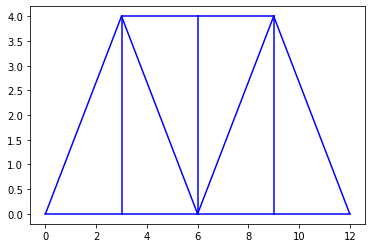

In [4]:
fig = plt.figure()

fig, ax = plt.subplots()

for k in A:
    ax.plot(np.transpose(B[k,0]),np.transpose(B[k,1]), color='b')

Nå kan vi komme i gang med oppbygging av matrisen som brukes i det lineære systemet:
   

In [5]:
C = np.zeros(2)
for k in A:
    v = B[k[1],:]-B[k[0],:]
    v = v/np.linalg.norm(v)
    C = np.vstack([C,v])
C = np.delete(C,0,0)

print(C)

[[ 1.   0. ]
 [ 0.6  0.8]
 [ 0.   1. ]
 [ 1.   0. ]
 [ 0.6 -0.8]
 [ 1.   0. ]
 [ 0.   1. ]
 [ 1.   0. ]
 [ 0.6  0.8]
 [ 1.   0. ]
 [ 0.   1. ]
 [ 1.   0. ]
 [ 0.6 -0.8]]


Hva er denne matrisen?

In [9]:
L=np.zeros([4*m,4*m])

for l in np.arange(np.size(A,0)):
    L[2*A[l,0],l] = C[l,0]
    L[2*A[l,0]+1,l] = C[l,1]
    L[2*A[l,1],l] = -C[l,0]
    L[2*A[l,1]+1,l] = -C[l,1]
    
q = np.size(A,0)    
    
L[0,q]=1
L[1,q+1]=1
L[4*m-1,q+2]=1

print(L)

[[ 1.   0.6  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   1.
   0.   0. ]
 [ 0.   0.8  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   1.   0. ]
 [-1.   0.   0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0. ]
 [-0.   0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0. ]
 [ 0.  -0.6 -0.   0.   0.6  1.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0. ]
 [ 0.  -0.8 -1.   0.  -0.8  0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0. ]
 [ 0.   0.   0.  -1.  -0.6  0.   0.   1.   0.6  0.   0.   0.   0.   0.
   0.   0. ]
 [ 0.   0.   0.  -0.   0.8  0.   1.   0.   0.8  0.   0.   0.   0.   0.
   0.   0. ]
 [ 0.   0.   0.   0.   0.  -1.  -0.   0.   0.   1.   0.   0.   0.   0.
   0.   0. ]
 [ 0.   0.   0.   0.   0.  -0.  -1.   0.   0.   0.   0.   0.   0.   0.
   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.  -1.   0.   0.   0.   1.   0.   0.
   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.  -0.   0.   0.   1.   0.   0.   0.
   0.

Da er mesterverket nesten ferdig - vi har fått til venstre side av det lineære systemet vi skal løse. Nå må vi ha en vektor av belastninger (også tatt fra Bell):

In [7]:
F=np.zeros([4*m,1])

F[3,0]=12
F[7,0]=20
F[11,0]=12

print(F)

[[ 0.]
 [ 0.]
 [ 0.]
 [12.]
 [ 0.]
 [ 0.]
 [ 0.]
 [20.]
 [ 0.]
 [ 0.]
 [ 0.]
 [12.]
 [ 0.]
 [ 0.]
 [ 0.]
 [ 0.]]


## Del 2 - Løs systemet

Når vi skal løse systemet, er det rett frem med datamaskin. I den virkelige verden, de lineære systemene som oppstår fra konstruksjonsanalyse er ofte såpass store at de ikke lar seg gjøre med Gauss-eliminasjon, og man må heller bruke numeriske metoder (se Programmering, Numerikk og Sikkerhet). Akkurat nå derimot er det ingen slike problemer.

In [10]:
strekk = np.linalg.solve(L,F)

print(strekk)

[[ 16.5]
 [-27.5]
 [ 12. ]
 [ 16.5]
 [ 12.5]
 [-24. ]
 [  0. ]
 [ 16.5]
 [ 12.5]
 [-24. ]
 [ 12. ]
 [ 16.5]
 [-27.5]
 [  0. ]
 [ 22. ]
 [ 22. ]]


## Del 3 - Tolkning av resultatene

Vi må kunne være i stand til å tolke og bruke resultatene, ellers er alt arbeidet forgjeves. Derfor kommer noen oppgaver!

# Oppgaver:

## Tolkning av fagverket over
1. Hva slags fester har vi til bakken? Glidelager eller fastlager? Hvilke noder?
2. Er systemet statisk bestemt? 
3. Er det strekk eller trykk i stav 4? Hvor mye?

## Et nytt fagverk

4. Du skal sette opp en bru i fagverk som skal krysse en elv som er 50m bred. Ingen av stavene skal være lengere enn 5m. Modifiser derfor $A$, $B$ og $L$ for å modellere den.
5. En lastebil kjører over brua. Den er 15m lang og veier 10 tonn. Anta at vekten er fordelt lik mellom alle knutepunkter som er festet til stavene lastebilen er på. Velg en posisjon for lastebilen og sett opp $\vec{f}$.
6. Løs systemet. Hva er maks strekk og trykk i fagverket?
7. Prøv en annen posisjon på lastebilen. Har det noe å si for maks strekk/trykk?

## Diskusjon om fagverk og lineær algebra:

Det er ikke alltid så lett å forstå forholdet mellom matematikk slik det er presentert i matte-timen og i anvendte sammenhenger (her mekanikk). Her er noen spørsmål det kan være verdt å diskutere innad i gruppe, for å hjelpe til å belyse denne sammenheng:

* Hvordan kan vi tolke 'snittmetoden' matematisk? Skriv ned (eller evt programmer) matrisen til et fagverk ved snittmetoden, og sammenlign det met knutepunktmetoden. Hva er forholdet? Kan en endres til den andre ved hjelp av radoperasjoner?
* Se for deg en tilfeldig matriseligning. Kunne det ha kommet fra et fagverk? 
* Symmetrier. I mekanikk er det utstrakt bruk av symmetrier: vi kan gjette at visse komponenter i løsningen må være identisk ut ifra symmetrier i problemet. Hvordan funker det rent matematisk? Når kan man anvende symmetrier på ligningssystemer som ikke nødvendigvis har sitt opphva i fagverk?